In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report


# Water potability

In [2]:
dataset = pd.read_csv('../datasets/water_potability.csv')

In [3]:
dataset.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [4]:
print("Dimensiones originales del dataset:", dataset.shape)
print("\nCantidad de valores faltantes por columna:")
print(dataset.isnull().sum())

Dimensiones originales del dataset: (3276, 10)

Cantidad de valores faltantes por columna:
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64


In [5]:
dataset = dataset.dropna()
print("Dimensiones después de eliminar filas con NaN:", dataset.shape)

Dimensiones después de eliminar filas con NaN: (2011, 10)


In [13]:
dataset['ph_lineal'] = abs(dataset['ph'] - 7.0)
dataset = dataset.drop(columns=['ph'])

In [14]:
X = dataset.drop(columns=['Potability'])
y = dataset['Potability']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=16)

In [16]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg = LogisticRegression(random_state=16, class_weight='balanced')
logreg.fit(X_train_scaled, y_train)

y_pred = logreg.predict(X_test_scaled)

In [17]:
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
cnf_matrix

array([[166, 144],
       [ 81, 112]])

Text(0.5, 427.9555555555555, 'Predicted label')

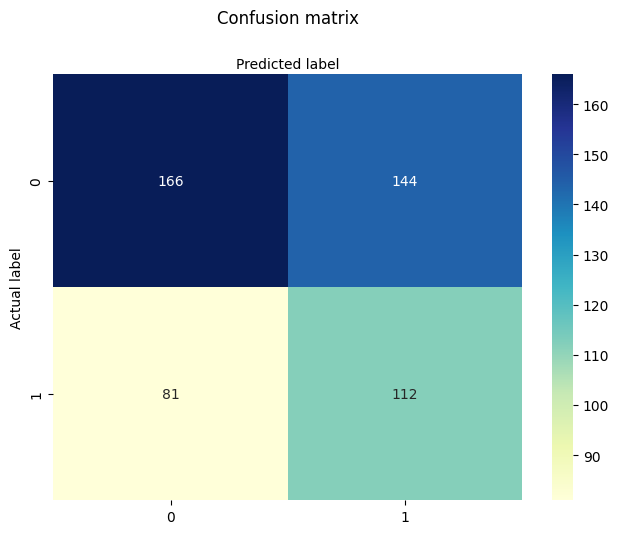

In [18]:
class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

In [19]:
target_names = ['Not potable', 'Potable']
print(classification_report(y_test, y_pred, target_names=target_names))

              precision    recall  f1-score   support

 Not potable       0.67      0.54      0.60       310
     Potable       0.44      0.58      0.50       193

    accuracy                           0.55       503
   macro avg       0.55      0.56      0.55       503
weighted avg       0.58      0.55      0.56       503



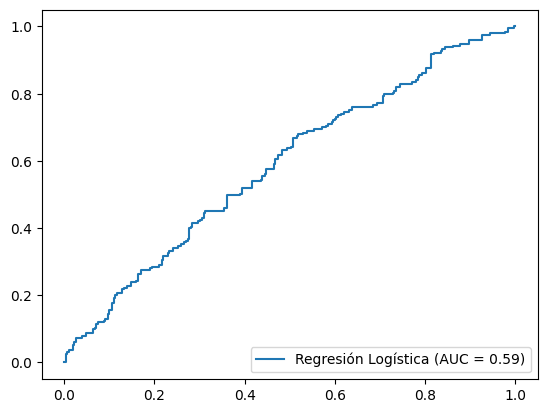

In [20]:
y_pred_proba = logreg.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, _ = metrics.roc_curve(y_test, y_pred_proba)
auc = metrics.roc_auc_score(y_test, y_pred_proba)

# Graficar
plt.plot(fpr, tpr, label=f"Regresión Logística (AUC = {auc:.2f})")
plt.legend(loc=4) 
plt.show()

# Reflexión

Elegí un conjunto de datos del mundo real sobre la potabilidad del agua. Mi experiencia preparando los datos fue un trabajo distinto al de regresión lineal en temas de limpieza; esto ya que tuve que analizar la distribución de valores faltantes en columnas críticas como el pH y los sulfatos, y aplicar métodos de descarte (como .dropna()) para garantizar una matriz limpia y funcional.

La mayor dificultad, y a la vez el resultado más revelador de toda la práctica, ocurrió al evaluar el modelo. Decidí implementar una Regresión Logística escalando previamente los datos con StandardScaler para evitar sesgos por la magnitud de variables como los sólidos disueltos, esto debido a que sin esto el modelo topa en su límite establecido. Sin embargo, al generar el reporte de clasificación y la matriz de confusión, obtuve una exactitud (Accuracy) de apenas el 55%. Al principio, este resultado parecía indicar un error en el código, ya que el modelo estaba prediciendo prácticamente al azar.

Al analizar a fondo este resultado,comprendí que la Regresión Logística es un clasificador lineal que intenta dibujar un único hiperplano recto para separar las clases. No obstante, las propiedades químicas del agua pueden tener comportamientos no lineales. Por ejemplo, el pH hace que el agua sea potable solo en un rango medio (cerca de 7), pero la hace peligrosa en ambos extremos (muy ácida o muy alcalina); por esto se optó por una linealización con el valor absoluto respecto al centro (es decir el 7). Lo que aprendí es que un dataset limpio no garantiza un modelo predictivo útil si la naturaleza matemática del algoritmo elegido no hace match con la realidad física del problema, justificando así la necesidad de explorar algoritmos no lineales como Árboles de Decisión para este tipo de escenarios.